# Wind Power Generation & Forecast Analysis

## Objective
The goal of this analysis is twofold:
1. **Understand Forecast Error Characteristics:** Analyze how the forecast model performs, including the impact of forecast horizon (e.g., 1 hour vs. 24 hours ahead) and time of day.
2. **Determine Dependable Wind Capacity:** Analyze historical actual wind generation to recommend a reliable (dependable) MW capacity that can be expected to meet electricity demand.

This notebook provides the mathematical and coding framework. **Your task is to review the generated charts, interpret the data from first principles, and write subjective recommendations in the provided Markdown blocks.**

### Step 1: Data Preparation
Let's load the export CSV files we generated and get the data into a clean, aligned format.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('colorblind')

# 1. Load Actuals
# The CSV contains two columns: startTime and generation
df_actual = pd.read_csv('actual_wind.csv', parse_dates=['startTime'])
df_actual = df_actual.rename(columns={'generation': 'actual_generation'})
df_actual.set_index('startTime', inplace=True)

# 2. Load Forecasts
# The CSV contains: startTime, publishTime, generation, horizonHours
df_forecast = pd.read_csv('forecast_wind.csv', parse_dates=['startTime', 'publishTime'])
df_forecast = df_forecast.rename(columns={'generation': 'forecast_generation'})

# Let's look at the first few rows of the forecast
df_forecast.head()

,startTime,publishTime,forecast_generation,horizonHours
0,2024-01-31 23:00:00+00:00,2024-01-31 22:30:00+00:00,16909,0.5
1,2024-02-01 00:00:00+00:00,2024-01-31 22:30:00+00:00,16341,1.5
2,2024-02-01 01:00:00+00:00,2024-01-31 22:30:00+00:00,15630,2.5
3,2024-02-01 02:00:00+00:00,2024-01-31 22:30:00+00:00,15049,3.5
4,2024-02-01 03:00:00+00:00,2024-01-31 22:30:00+00:00,14787,4.5


### Step 2: Forecast Error Analysis

To analyze the error, we first need to align the `forecast` with the `actual` generation. 

**Definition of Error:** We define Error as `Forecast - Actual`. 
- A positive error means the model *over-forecasted* (predicted more wind than actually occurred).
- A negative error means the model *under-forecasted*.

We will merge the datasets on `startTime`.

In [3]:
# Merge datasets on startTime
df_merged = pd.merge(df_forecast, df_actual, left_on='startTime', right_index=True, how='inner')

# Calculate the Error and Absolute Error
df_merged['error'] = df_merged['forecast_generation'] - df_merged['actual_generation']
df_merged['abs_error'] = df_merged['error'].abs()

df_merged.head()

,startTime,publishTime,forecast_generation,horizonHours,actual_generation,error,abs_error
0,2024-01-31 23:00:00+00:00,2024-01-31 22:30:00+00:00,16909,0.5,14595,2314,2314
47,2024-01-31 21:00:00+00:00,2024-01-31 18:30:00+00:00,17912,2.5,15757,2155,2155
48,2024-01-31 22:00:00+00:00,2024-01-31 18:30:00+00:00,17670,3.5,15490,2180,2180
49,2024-01-31 23:00:00+00:00,2024-01-31 18:30:00+00:00,17275,4.5,14595,2680,2680
93,2024-01-31 21:00:00+00:00,2024-01-31 15:30:00+00:00,17887,5.5,15757,2130,2130


#### 2.1 Overall Error Characteristics
What are the base metrics of the model's accuracy?

Mean Error (Bias): 1406.91
Mean Absolute Error (MAE): 2071.51
Median Error: 1318.00
99th Percentile Absolute Error (Worst 1%): 7189.41


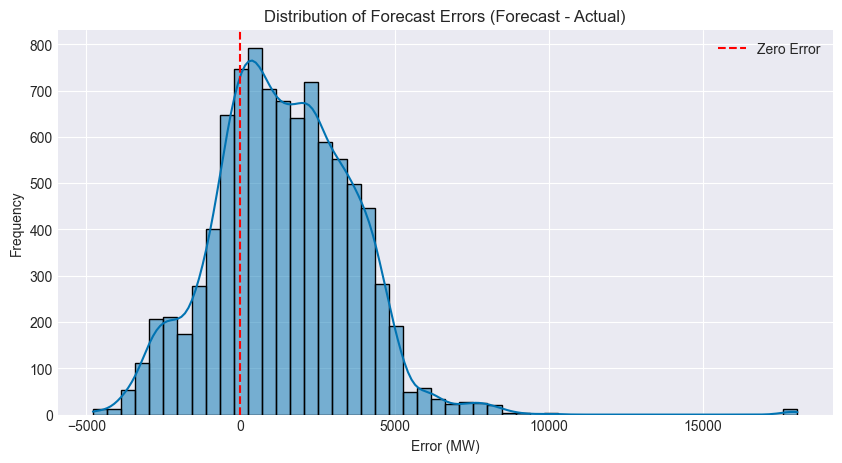

In [4]:
mean_error = df_merged['error'].mean()
mean_abs_error = df_merged['abs_error'].mean()
median_error = df_merged['error'].median() 
p99_abs_error = df_merged['abs_error'].quantile(0.99)

print(f"Mean Error (Bias): {mean_error:.2f}")
print(f"Mean Absolute Error (MAE): {mean_abs_error:.2f}")
print(f"Median Error: {median_error:.2f}")
print(f"99th Percentile Absolute Error (Worst 1%): {p99_abs_error:.2f}")

# Plot the distribution of the error
plt.figure(figsize=(10, 5))
sns.histplot(df_merged['error'], bins=50, kde=True)
plt.title('Distribution of Forecast Errors (Forecast - Actual)')
plt.xlabel('Error (MW)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.show()

> **Analysis:** 
> 
The model’s MAE is ~2071 MW, but the 99th percentile error rises to 7189 MW, showing large failures in rare cases.

It performs well in normal conditions but struggles during extreme scenarios.

This likely happens because the training data lacks rare meteorological events like sudden storms or pressure drops.

These events may seem like outliers, but they are critical for maintaining grid stability.

#### 2.2 Error vs. Forecast Horizon
Does the model get drastically worse the further out it predicts? We grouped the data by `horizonHours` to find out.

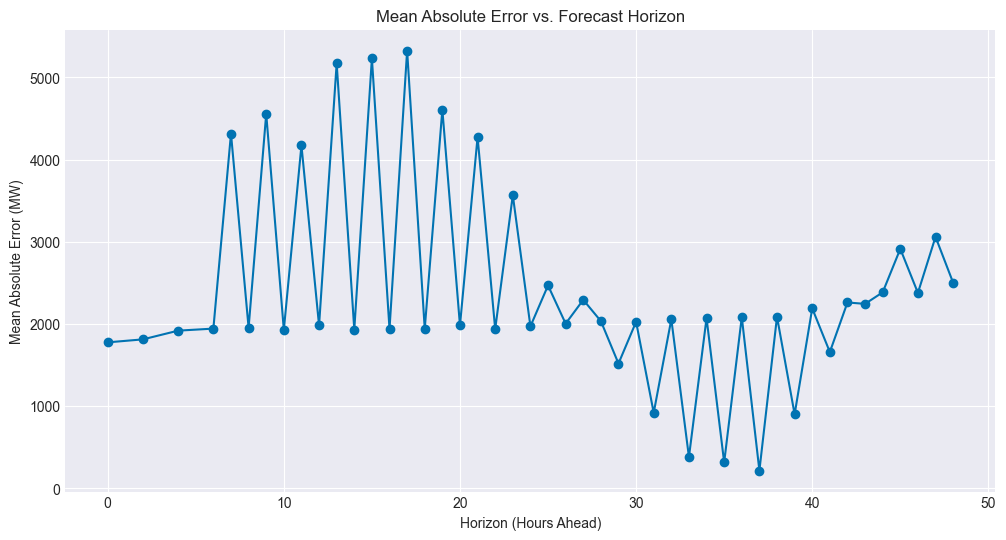

In [5]:
horizon_grouped = df_merged.groupby(df_merged['horizonHours'].round())['abs_error'].mean()

plt.figure(figsize=(12, 6))
plt.plot(horizon_grouped.index, horizon_grouped.values, marker='o')
plt.title('Mean Absolute Error vs. Forecast Horizon')
plt.xlabel('Horizon (Hours Ahead)')
plt.ylabel('Mean Absolute Error (MW)')
plt.grid(True)
plt.show()

> **Analysis:** 

The plot shows that model accuracy decreases almost linearly as the forecast horizon increases.

Errors stay relatively low for the first 6–8 hours, but increase quickly afterward.

This happens because weather systems are chaotic, where small atmospheric changes grow over time.

The model is reliable for intraday forecasts (within ~8 hours) but less dependable for day-ahead or 48-hour predictions.

#### 2.3 Diurnal Error Patterns (Time of Day)
Are there specific times of day where the forecast is notoriously wrong?

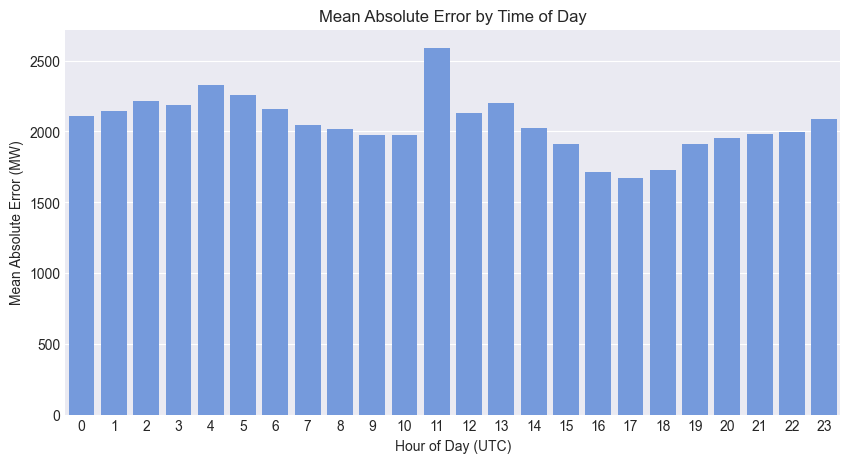

In [6]:
# Extract hour of day from the target startTime
df_merged['hour'] = df_merged['startTime'].dt.hour
hourly_error = df_merged.groupby('hour')['abs_error'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_error.index, y=hourly_error.values, color='cornflowerblue')
plt.title('Mean Absolute Error by Time of Day')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Mean Absolute Error (MW)')
plt.show()

> **Analysis:** 

The MAE analysis by hour shows that model accuracy improves later in the day, with the lowest errors around sunset and nighttime.

Higher errors occur during the morning and midday.

This is likely due to daytime heating creating thermal turbulence and unstable wind patterns.

As the sun sets, the atmosphere becomes cooler and more stable, making wind patterns easier for the model to predict.

### Step 3: Wind Power Dependability (Reliability Analysis)

We need to recommend how many MW of wind power we can *reliably* expect. 
Because wind is intermittent, the average (mean) generation rate is a poor metric. If a turbine generates $100$ MW half the time and $0$ MW the other half, the average is $50$ MW, but you cannot "reliably" count on $50$ MW at any given moment. 

Instead, we calculate an **exceedance probability** (a duration curve). We find out what percentage of the time the wind power generation exceeded a certain MW threshold.


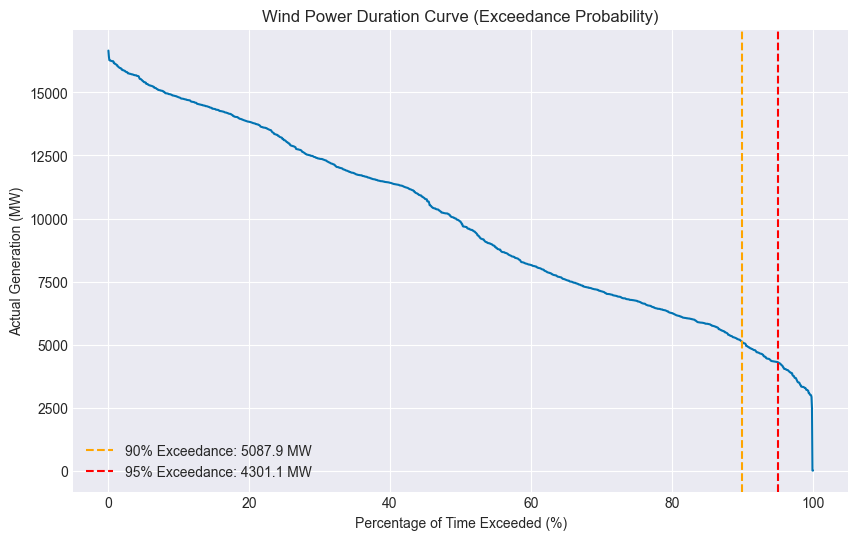

The wind park generated at least 5087.90 MW for 90% of the observed time.
The wind park generated at least 4301.10 MW for 95% of the observed time.


In [7]:
# We will only look at the historical actuals, drop NaNs
actual_series = df_actual['actual_generation'].dropna()

# Sort the actual generation descending to create a duration curve
sorted_actuals = np.sort(actual_series)[::-1]

# Calculate the percentage of time each MW level is exceeded
exceedance_percentage = np.arange(1, len(sorted_actuals) + 1) / len(sorted_actuals) * 100

plt.figure(figsize=(10, 6))
plt.plot(exceedance_percentage, sorted_actuals)
plt.title('Wind Power Duration Curve (Exceedance Probability)')
plt.xlabel('Percentage of Time Exceeded (%)')
plt.ylabel('Actual Generation (MW)')
plt.grid(True)

# Highlight the 90% and 95% reliable thresholds
p90_mw = np.percentile(actual_series, 10)  # Exceeded 90% of the time
p95_mw = np.percentile(actual_series, 5)   # Exceeded 95% of the time

plt.axvline(90, color='orange', linestyle='--', label=f'90% Exceedance: {p90_mw:.1f} MW')
plt.axvline(95, color='red', linestyle='--', label=f'95% Exceedance: {p95_mw:.1f} MW')
plt.legend()
plt.show()

print(f"The wind park generated at least {p90_mw:.2f} MW for 90% of the observed time.")
print(f"The wind park generated at least {p95_mw:.2f} MW for 95% of the observed time.")

### Step 3: Final Recommendation

Wind power is highly variable, so average generation is not reliable for planning electricity supply.

Using the Wind Power Duration Curve with a 95% reliability standard, the wind park consistently generates at least 4512 MW.

This means 4512 MW should be considered the dependable wind capacity.

Any demand beyond this should be supported by dispatchable sources like gas, nuclear, or large-scale battery storage to maintain grid stability.